# Home Credit Default Risk: Preprocessing and Feature Engineering

Notebook 2 of 5. It turns the application table and six history tables into one row per applicant, fixes the holdout split used by every later notebook, and writes the feature matrix that notebooks 3, 4 and 5 consume.

Decisions carried over from the EDA: flag and blank the `DAYS_EMPLOYED` placeholder, combine the three external scores, express amounts as ratios, split bureau loans into active and closed, split previous applications into approved and refused, and add recent time windows for payment behaviour.

## Setup

Imports, paths and helpers. `find_file` searches the Kaggle inputs, `save` writes figures to `figures/`, and `elapsed` reports runtime so the cost of each table is visible. `SMOKE` is a switch for a quick check run on 20,000 applicants before the full run; it is off in this version.

In [1]:
import gc
import json
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
SMOKE = False
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SEED = 42
AGE_LABELS = ["<30", "30-39", "40-49", "50-59", "60+"]
SEGMENT_COLS = ["NAME_CONTRACT_TYPE", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "REGION_RATING_CLIENT"]
PREFIX_GROUPS = [
    ("X_", "cross_table"), ("BURO_", "bureau"), ("ACTIVE_", "bureau"), ("CLOSED_", "bureau"),
    ("PREV_", "previous"), ("APPROVED_", "previous"), ("REFUSED_", "previous"),
    ("POS_", "pos_cash"), ("CC_", "credit_card"), ("INS_", "installments"),
]
sns.set_theme(style="whitegrid", palette="deep")
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()


def elapsed():
    return f"{(time.time() - START) / 60:.1f} min"


def clean(name):
    return re.sub(r"[^0-9A-Za-z]+", "_", str(name)).strip("_").upper()


def one_hot(df):
    cats = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    before = set(df.columns)
    df = pd.get_dummies(df, columns=cats, dummy_na=True, dtype=np.uint8)
    df.columns = [c if c in before else clean(c) for c in df.columns]
    return df, [c for c in df.columns if c not in before]


def aggregate(df, aggs, prefix, key="SK_ID_CURR"):
    aggs = {col: stats for col, stats in aggs.items() if col in df.columns}
    out = df.groupby(key).agg(aggs)
    out.columns = [f"{prefix}{col}_{stat}".upper() for col, stat in out.columns]
    return out


def report(name, frame):
    print(f"{name}: {frame.shape[0]:,} applicants x {frame.shape[1]} features")
    print(f"elapsed {elapsed()}")


def group_of(col):
    return next((group for prefix, group in PREFIX_GROUPS if col.startswith(prefix)), "application")


print(f"smoke={SMOKE}")

smoke=False


**Conclusion.** The smoke switch is off, so this run builds features for every applicant.

## Application features

Aim: build the applicant-level features. The `DAYS_EMPLOYED` placeholder becomes missing plus a flag, the external scores are combined, and raw amounts become ratios (credit to annuity approximates loan term; annuity to income measures payment burden). Text categories are label-encoded to integers, with -1 for missing, and the raw segment labels are kept aside for the scorecard.

In [2]:
app = pd.read_csv(find_file("application_train.csv"))
if SMOKE:
    app = app.sample(n=20000, random_state=SEED).reset_index(drop=True)
print(f"applicants loaded: {len(app):,}")
age_years = -app["DAYS_BIRTH"] / 365
segments = app[["SK_ID_CURR"] + SEGMENT_COLS].rename(columns={c: f"SEG_{c}" for c in SEGMENT_COLS})
segments["SEG_AGE_BAND"] = pd.cut(age_years, bins=[0, 30, 40, 50, 60, 120], right=False, labels=AGE_LABELS)
segments = segments.astype({c: str for c in segments.columns if c.startswith("SEG_")})
segments["EAD"] = app["AMT_CREDIT"]
segments = segments.set_index("SK_ID_CURR")

app["DAYS_EMPLOYED_ANOM"] = (app["DAYS_EMPLOYED"] == 365243).astype(np.uint8)
app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].replace(365243, np.nan)
ext = app[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]]
new = {
    "EXT_MEAN": ext.mean(axis=1),
    "EXT_STD": ext.std(axis=1),
    "EXT_MIN": ext.min(axis=1),
    "EXT_MAX": ext.max(axis=1),
    "EXT_PROD": ext.prod(axis=1, min_count=3),
    "EXT_WEIGHTED": 2 * app["EXT_SOURCE_1"] + app["EXT_SOURCE_2"] + 3 * app["EXT_SOURCE_3"],
    "EXT_MISSING": ext.isna().sum(axis=1),
    "CREDIT_TO_ANNUITY": app["AMT_CREDIT"] / app["AMT_ANNUITY"],
    "ANNUITY_TO_INCOME": app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"],
    "CREDIT_TO_GOODS": app["AMT_CREDIT"] / app["AMT_GOODS_PRICE"],
    "CREDIT_TO_INCOME": app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"],
    "CREDIT_MINUS_GOODS": app["AMT_CREDIT"] - app["AMT_GOODS_PRICE"],
    "INCOME_PER_PERSON": app["AMT_INCOME_TOTAL"] / app["CNT_FAM_MEMBERS"],
    "EMPLOYED_TO_BIRTH": app["DAYS_EMPLOYED"] / app["DAYS_BIRTH"],
    "REGISTRATION_TO_BIRTH": app["DAYS_REGISTRATION"] / app["DAYS_BIRTH"],
    "ID_PUBLISH_TO_BIRTH": app["DAYS_ID_PUBLISH"] / app["DAYS_BIRTH"],
    "PHONE_TO_BIRTH": app["DAYS_LAST_PHONE_CHANGE"] / app["DAYS_BIRTH"],
    "CAR_TO_AGE": app["OWN_CAR_AGE"] / age_years,
    "DOCUMENT_COUNT": app.filter(like="FLAG_DOCUMENT_").sum(axis=1),
    "ENQUIRY_TOTAL": app.filter(like="AMT_REQ_CREDIT_BUREAU_").sum(axis=1, min_count=1),
    "SOCIAL_DEFAULT_RATIO": app["DEF_30_CNT_SOCIAL_CIRCLE"] / app["OBS_30_CNT_SOCIAL_CIRCLE"],
}
app = pd.concat([app, pd.DataFrame(new)], axis=1)
categorical = {}
for col in [c for c in app.columns if not pd.api.types.is_numeric_dtype(app[c])]:
    codes = app[col].astype("category")
    categorical[col] = [str(v) for v in codes.cat.categories]
    app[col] = codes.cat.codes.astype(np.int16)
app = app.set_index("SK_ID_CURR")
IDS = app.index.to_numpy()
print(f"label-encoded categoricals: {len(categorical)}")
report("application", app)

applicants loaded: 307,511
label-encoded categoricals: 16
application: 307,511 applicants x 143 features
elapsed 0.3 min


**Conclusion.** All 307,511 applicants loaded. The 122 original columns plus the anomaly flag and 21 engineered columns give 143 application-level columns (the target included), and the 16 text columns were label-encoded with their category labels saved for the dashboard.

## Bureau and bureau balance

Aim: summarise each applicant's loans at other lenders. Monthly balance records are first rolled up per bureau loan (months on record, share of late months overall and in the last 12 months), then every loan is aggregated per applicant three ways: all loans, active loans and closed loans, plus a two year window.

In [3]:
bureau = pd.read_csv(find_file("bureau.csv"))
bureau = bureau[bureau["SK_ID_CURR"].isin(IDS)]
bb = pd.read_csv(find_file("bureau_balance.csv"))
bb = bb[bb["SK_ID_BUREAU"].isin(bureau["SK_ID_BUREAU"])]
status = pd.get_dummies(bb["STATUS"], prefix="STATUS", dtype=np.uint8)
status.columns = [clean(c) for c in status.columns]
late_cols = [c for c in status.columns if c in ("STATUS_1", "STATUS_2", "STATUS_3", "STATUS_4", "STATUS_5")]
bb = pd.concat([bb[["SK_ID_BUREAU", "MONTHS_BALANCE"]], status], axis=1)
bb["LATE"] = bb[late_cols].max(axis=1)
per_loan = aggregate(bb, {"MONTHS_BALANCE": ["min", "size"], "LATE": ["mean", "sum"], **{c: ["mean"] for c in status.columns}}, "BB_", key="SK_ID_BUREAU")
per_loan["BB_LATE_MEAN_12M"] = bb[bb["MONTHS_BALANCE"] >= -12].groupby("SK_ID_BUREAU")["LATE"].mean()
bureau = bureau.join(per_loan, on="SK_ID_BUREAU")
del bb, status, per_loan
gc.collect()

bureau["DEBT_TO_CREDIT"] = bureau["AMT_CREDIT_SUM_DEBT"] / bureau["AMT_CREDIT_SUM"]
bureau["OVERDUE_TO_CREDIT"] = bureau["AMT_CREDIT_SUM_OVERDUE"] / bureau["AMT_CREDIT_SUM"]
bureau["LIMIT_TO_CREDIT"] = bureau["AMT_CREDIT_SUM_LIMIT"] / bureau["AMT_CREDIT_SUM"]
bureau["ANNUITY_TO_CREDIT"] = bureau["AMT_ANNUITY"] / bureau["AMT_CREDIT_SUM"]
bureau["ENDDATE_GAP"] = bureau["DAYS_CREDIT_ENDDATE"] - bureau["DAYS_ENDDATE_FACT"]
bureau, bureau_cats = one_hot(bureau)
bureau_num = {
    "DAYS_CREDIT": ["min", "max", "mean", "var"],
    "DAYS_CREDIT_ENDDATE": ["min", "max", "mean"],
    "DAYS_CREDIT_UPDATE": ["mean"],
    "CREDIT_DAY_OVERDUE": ["max", "mean"],
    "AMT_CREDIT_MAX_OVERDUE": ["max", "mean"],
    "AMT_CREDIT_SUM": ["max", "mean", "sum"],
    "AMT_CREDIT_SUM_DEBT": ["max", "mean", "sum"],
    "AMT_CREDIT_SUM_OVERDUE": ["mean", "sum"],
    "AMT_CREDIT_SUM_LIMIT": ["mean", "sum"],
    "AMT_ANNUITY": ["max", "mean", "sum"],
    "CNT_CREDIT_PROLONG": ["sum"],
    "DEBT_TO_CREDIT": ["max", "mean"],
    "OVERDUE_TO_CREDIT": ["max", "mean"],
    "LIMIT_TO_CREDIT": ["mean"],
    "ANNUITY_TO_CREDIT": ["mean"],
    "ENDDATE_GAP": ["mean"],
    "BB_MONTHS_BALANCE_MIN": ["min"],
    "BB_MONTHS_BALANCE_SIZE": ["mean", "sum"],
    "BB_LATE_MEAN": ["mean", "max"],
    "BB_LATE_SUM": ["sum"],
    "BB_LATE_MEAN_12M": ["mean", "max"],
    "BB_STATUS_0_MEAN": ["mean"],
    "BB_STATUS_C_MEAN": ["mean"],
    "BB_STATUS_X_MEAN": ["mean"],
}
bureau_feats = aggregate(bureau, {**bureau_num, **{c: ["mean"] for c in bureau_cats}}, "BURO_")
bureau_feats = bureau_feats.join(aggregate(bureau[bureau["CREDIT_ACTIVE_ACTIVE"] == 1], bureau_num, "ACTIVE_"))
bureau_feats = bureau_feats.join(aggregate(bureau[bureau["CREDIT_ACTIVE_CLOSED"] == 1], bureau_num, "CLOSED_"))
recent = {"AMT_CREDIT_SUM": ["sum", "mean"], "DEBT_TO_CREDIT": ["mean"], "SK_ID_BUREAU": ["count"]}
bureau_feats = bureau_feats.join(aggregate(bureau[bureau["DAYS_CREDIT"] >= -730], recent, "BURO_2Y_"))
bureau_feats["BURO_COUNT"] = bureau.groupby("SK_ID_CURR").size()
del bureau
gc.collect()
report("bureau", bureau_feats)

bureau: 263,491 applicants x 163 features
elapsed 1.1 min


**Conclusion.** 263,491 applicants (85.7%) have at least one bureau loan, matching the coverage seen in the EDA, and each now carries 163 bureau features covering all loans, active loans, closed loans and the last two years. Applicants with no bureau history will have missing values here, which the tree models handle directly.

## Previous Home Credit applications

Aim: summarise each applicant's earlier applications with Home Credit. Placeholder dates become missing, ratios describe how much was requested versus granted, a simple rate estimates the loan's interest, and loans still being repaid are marked active. Aggregates are built for all, approved and refused applications, plus the most recent 3 and 5.

In [4]:
prev = pd.read_csv(find_file("previous_application.csv"))
prev = prev[prev["SK_ID_CURR"].isin(IDS)]
for col in ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]:
    prev[col] = prev[col].replace(365243, np.nan)
prev["APP_TO_CREDIT"] = prev["AMT_APPLICATION"] / prev["AMT_CREDIT"]
prev["CREDIT_TO_ANNUITY"] = prev["AMT_CREDIT"] / prev["AMT_ANNUITY"]
prev["DOWN_TO_CREDIT"] = prev["AMT_DOWN_PAYMENT"] / prev["AMT_CREDIT"]
prev["GOODS_TO_CREDIT"] = prev["AMT_GOODS_PRICE"] / prev["AMT_CREDIT"]
prev["DUE_GAP"] = prev["DAYS_LAST_DUE_1ST_VERSION"] - prev["DAYS_LAST_DUE"]
prev["SIMPLE_RATE"] = (prev["AMT_ANNUITY"] * prev["CNT_PAYMENT"] / prev["AMT_CREDIT"] - 1) / prev["CNT_PAYMENT"]
prev["ACTIVE"] = (prev["DAYS_LAST_DUE_1ST_VERSION"] > 0).astype(np.uint8)
prev["REMAINING_CREDIT"] = prev["AMT_CREDIT"] * prev["ACTIVE"]
status = prev["NAME_CONTRACT_STATUS"].to_numpy()
active_annuity = prev[prev["ACTIVE"] == 1].groupby("SK_ID_CURR")["AMT_ANNUITY"].sum()
prev, prev_cats = one_hot(prev)
prev_num = {
    "AMT_ANNUITY": ["min", "max", "mean", "sum"],
    "AMT_APPLICATION": ["min", "max", "mean"],
    "AMT_CREDIT": ["min", "max", "mean", "sum"],
    "APP_TO_CREDIT": ["min", "max", "mean", "var"],
    "CREDIT_TO_ANNUITY": ["mean", "max"],
    "AMT_DOWN_PAYMENT": ["min", "max", "mean"],
    "AMT_GOODS_PRICE": ["min", "max", "mean"],
    "HOUR_APPR_PROCESS_START": ["min", "max", "mean"],
    "RATE_DOWN_PAYMENT": ["min", "max", "mean"],
    "DOWN_TO_CREDIT": ["mean"],
    "GOODS_TO_CREDIT": ["mean"],
    "DAYS_DECISION": ["min", "max", "mean"],
    "CNT_PAYMENT": ["mean", "sum"],
    "DUE_GAP": ["mean", "max"],
    "SIMPLE_RATE": ["min", "max", "mean"],
    "DAYS_TERMINATION": ["max", "mean"],
    "DAYS_LAST_DUE_1ST_VERSION": ["max", "mean"],
    "ACTIVE": ["sum", "mean"],
    "REMAINING_CREDIT": ["sum"],
}
prev_feats = aggregate(prev, {**prev_num, **{c: ["mean"] for c in prev_cats}}, "PREV_")
prev_feats = prev_feats.join(aggregate(prev[status == "Approved"], prev_num, "APPROVED_"))
prev_feats = prev_feats.join(aggregate(prev[status == "Refused"], prev_num, "REFUSED_"))
recent_aggs = {"AMT_CREDIT": ["mean"], "APP_TO_CREDIT": ["mean"], "CNT_PAYMENT": ["mean"], "SIMPLE_RATE": ["mean"], "DAYS_DECISION": ["mean"], "NAME_CONTRACT_STATUS_REFUSED": ["mean"]}
ordered = prev.sort_values(["SK_ID_CURR", "DAYS_DECISION"], ascending=[True, False])
for n in (3, 5):
    prev_feats = prev_feats.join(aggregate(ordered.groupby("SK_ID_CURR").head(n), recent_aggs, f"PREV_LAST{n}_"))
prev_feats["PREV_COUNT"] = prev.groupby("SK_ID_CURR").size()
prev_feats["PREV_ACTIVE_ANNUITY_SUM"] = active_annuity
del prev, ordered
gc.collect()
report("previous applications", prev_feats)

previous applications: 291,057 applicants x 316 features
elapsed 2.0 min


**Conclusion.** 291,057 applicants have previous Home Credit applications and receive 316 features. Most of them are shares of one-hot categories (contract type, loan purpose, sales channel, goods category and similar), alongside the approved, refused and most-recent aggregates.

## POS and cash loan balances

Aim: capture monthly repayment behaviour on point-of-sale and cash loans: days past due, how much of each loan remains, whether the latest status is completed, and the same signals over the last 12 months.

In [5]:
pos = pd.read_csv(find_file("POS_CASH_balance.csv"))
pos = pos[pos["SK_ID_CURR"].isin(IDS)]
pos["LATE"] = (pos["SK_DPD"] > 0).astype(np.uint8)
pos["LATE_DEF"] = (pos["SK_DPD_DEF"] > 0).astype(np.uint8)
pos["REMAINING_SHARE"] = pos["CNT_INSTALMENT_FUTURE"] / pos["CNT_INSTALMENT"]
pos, pos_cats = one_hot(pos)
pos_aggs = {
    "MONTHS_BALANCE": ["max", "mean", "size"],
    "SK_DPD": ["max", "mean"],
    "SK_DPD_DEF": ["max", "mean"],
    "LATE": ["mean", "sum"],
    "LATE_DEF": ["mean"],
    "CNT_INSTALMENT": ["mean", "max"],
    "CNT_INSTALMENT_FUTURE": ["mean", "sum"],
    "REMAINING_SHARE": ["mean", "min"],
    **{c: ["mean"] for c in pos_cats},
}
pos_feats = aggregate(pos, pos_aggs, "POS_")
pos_feats = pos_feats.join(aggregate(pos[pos["MONTHS_BALANCE"] >= -12], {"SK_DPD": ["max", "mean"], "LATE": ["mean"], "REMAINING_SHARE": ["mean"]}, "POS_12M_"))
latest = pos.sort_values("MONTHS_BALANCE", kind="stable").groupby("SK_ID_PREV").tail(1)
pos_feats = pos_feats.join(aggregate(latest, {"NAME_CONTRACT_STATUS_COMPLETED": ["mean"], "CNT_INSTALMENT_FUTURE": ["sum"], "REMAINING_SHARE": ["mean"]}, "POS_LATEST_"))
pos_feats["POS_LOAN_COUNT"] = pos.groupby("SK_ID_CURR")["SK_ID_PREV"].nunique()
del pos, latest
gc.collect()
report("POS and cash", pos_feats)

POS and cash: 289,444 applicants x 34 features
elapsed 2.7 min


**Conclusion.** 289,444 applicants get 34 POS and cash features, including the latest status of each loan and delinquency over the last 12 months.

## Credit card balances

Aim: describe revolving credit use: utilisation of the limit, payments against the required minimum, drawings and days past due, over the whole history and the last 12 months.

In [6]:
cc = pd.read_csv(find_file("credit_card_balance.csv"))
cc = cc[cc["SK_ID_CURR"].isin(IDS)]
cc["UTILIZATION"] = cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"]
cc["PAYMENT_TO_MIN"] = cc["AMT_PAYMENT_CURRENT"] / cc["AMT_INST_MIN_REGULARITY"]
cc["DRAWING_TO_LIMIT"] = cc["AMT_DRAWINGS_CURRENT"] / cc["AMT_CREDIT_LIMIT_ACTUAL"]
cc["LATE"] = (cc["SK_DPD"] > 0).astype(np.uint8)
cc, cc_cats = one_hot(cc)
cc_num = [c for c in cc.columns if c not in ("SK_ID_PREV", "SK_ID_CURR") and c not in cc_cats]
cc_feats = aggregate(cc, {**{c: ["min", "max", "mean", "sum", "var"] for c in cc_num}, **{c: ["mean"] for c in cc_cats}}, "CC_")
cc_feats = cc_feats.join(aggregate(cc[cc["MONTHS_BALANCE"] >= -12], {"UTILIZATION": ["mean", "max"], "LATE": ["mean"], "AMT_BALANCE": ["mean"], "PAYMENT_TO_MIN": ["mean"]}, "CC_12M_"))
cc_feats["CC_COUNT"] = cc.groupby("SK_ID_CURR").size()
del cc
gc.collect()
report("credit card", cc_feats)

credit card: 86,905 applicants x 134 features
elapsed 3.3 min


**Conclusion.** Only 86,905 applicants (28.3%) have credit card history, so these 134 features are missing for most applicants. They are kept because revolving behaviour is informative for the applicants who have it.

## Instalment payments

Aim: measure repayment discipline on previous loans: paid versus due amounts, days late and days early, the share of late or short payments, over the whole history, the last 12 months, and the last 10 instalments.

In [7]:
ins = pd.read_csv(find_file("installments_payments.csv"))
ins = ins[ins["SK_ID_CURR"].isin(IDS)]
ins["PAYMENT_RATIO"] = ins["AMT_PAYMENT"] / ins["AMT_INSTALMENT"]
ins["PAYMENT_DIFF"] = ins["AMT_INSTALMENT"] - ins["AMT_PAYMENT"]
ins["DPD"] = (ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]).clip(lower=0)
ins["DBD"] = (ins["DAYS_INSTALMENT"] - ins["DAYS_ENTRY_PAYMENT"]).clip(lower=0)
ins["LATE"] = (ins["DPD"] > 0).astype(np.uint8)
ins["UNDERPAID"] = (ins["PAYMENT_DIFF"] > 0).astype(np.uint8)
ins_aggs = {
    "NUM_INSTALMENT_VERSION": ["nunique"],
    "DPD": ["max", "mean", "sum"],
    "DBD": ["max", "mean", "sum"],
    "PAYMENT_RATIO": ["min", "max", "mean", "var"],
    "PAYMENT_DIFF": ["max", "mean", "sum", "var"],
    "LATE": ["mean", "sum"],
    "UNDERPAID": ["mean"],
    "AMT_INSTALMENT": ["max", "mean", "sum"],
    "AMT_PAYMENT": ["min", "max", "mean", "sum"],
    "DAYS_ENTRY_PAYMENT": ["max", "mean"],
}
window = {"DPD": ["max", "mean"], "DBD": ["mean"], "PAYMENT_RATIO": ["min", "mean"], "PAYMENT_DIFF": ["mean", "sum"], "LATE": ["mean"], "UNDERPAID": ["mean"]}
ins_feats = aggregate(ins, ins_aggs, "INS_")
ins_feats = ins_feats.join(aggregate(ins[ins["DAYS_INSTALMENT"] >= -365], window, "INS_12M_"))
last10 = ins.sort_values(["SK_ID_CURR", "DAYS_INSTALMENT"], ascending=[True, False]).groupby("SK_ID_CURR").head(10)
ins_feats = ins_feats.join(aggregate(last10, window, "INS_LAST10_"))
ins_feats["INS_COUNT"] = ins.groupby("SK_ID_CURR").size()
del ins, last10
gc.collect()
report("instalments", ins_feats)

instalments: 291,643 applicants x 46 features
elapsed 4.5 min


**Conclusion.** 291,643 applicants get 46 instalment features covering their whole history, the last 12 months and the last 10 instalments.

## Assemble the matrix and add cross-table ratios

Aim: join every table to the application rows, then add ratios that need two tables at once (total debt and annuity burden against income, remaining previous credit against income, instalments paid against the new credit). Infinite values from zero denominators become missing, constant columns are dropped, and everything is stored as float32.

constant columns dropped: 6
final matrix: 307,511 applicants x 836 features, 1.04 GB
previous        310
bureau          163
application     142
credit_card     134
installments     46
pos_cash         34
cross_table       7
elapsed 4.7 min


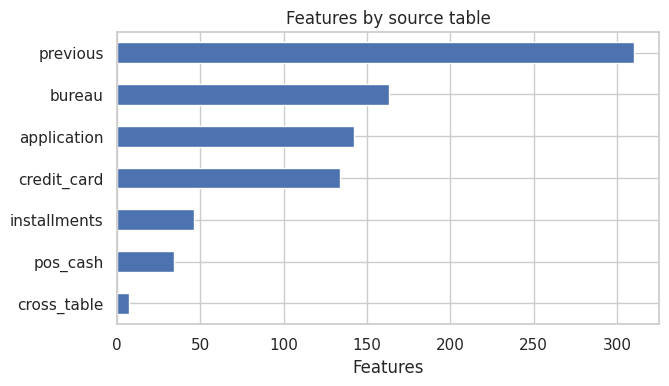

In [8]:
features = app.join([bureau_feats, prev_feats, pos_feats, cc_feats, ins_feats])
income = features["AMT_INCOME_TOTAL"]
cross = {
    "X_BURO_DEBT_TO_INCOME": features["ACTIVE_AMT_CREDIT_SUM_DEBT_SUM"] / income,
    "X_BURO_CREDIT_TO_INCOME": features["ACTIVE_AMT_CREDIT_SUM_SUM"] / income,
    "X_TOTAL_ANNUITY_TO_INCOME": (features["AMT_ANNUITY"] + features["ACTIVE_AMT_ANNUITY_SUM"].fillna(0) + features["PREV_ACTIVE_ANNUITY_SUM"].fillna(0)) / income,
    "X_PREV_REMAINING_TO_INCOME": features["PREV_REMAINING_CREDIT_SUM"] / income,
    "X_PREV_ANNUITY_TO_CURRENT": features["APPROVED_AMT_ANNUITY_MEAN"] / features["AMT_ANNUITY"],
    "X_INS_PAID_TO_CREDIT": features["INS_AMT_PAYMENT_SUM"] / features["AMT_CREDIT"],
    "X_CC_BALANCE_TO_INCOME": features["CC_AMT_BALANCE_MEAN"] / income,
}
features = pd.concat([features, pd.DataFrame(cross, index=features.index)], axis=1)
del bureau_feats, prev_feats, pos_feats, cc_feats, ins_feats
gc.collect()
target = features.pop("TARGET")
features = features.replace([np.inf, -np.inf], np.nan)
constant = [c for c in features.columns if features[c].nunique(dropna=False) <= 1]
features = features.drop(columns=constant).astype(np.float32)
assert features.columns.is_unique
groups = {c: group_of(c) for c in features.columns}
group_counts = pd.Series(groups).value_counts()
print(f"constant columns dropped: {len(constant)}")
print(f"final matrix: {features.shape[0]:,} applicants x {features.shape[1]} features, {features.memory_usage().sum() / 1e9:.2f} GB")
print(group_counts.to_string())
print(f"elapsed {elapsed()}")
fig, ax = plt.subplots(figsize=(7, 3.8))
group_counts.iloc[::-1].plot.barh(ax=ax)
ax.set_xlabel("Features")
ax.set_title("Features by source table")
save(fig, "01_feature_groups")

**Conclusion.** The final matrix has 307,511 applicants and 836 features after 6 constant columns were dropped, taking 1.04 GB as float32. Previous applications contribute the most features (310), followed by bureau (163), application (142), credit card (134), instalments (46), POS and cash (34) and the 7 cross-table ratios. The whole build took a few minutes on Kaggle's CPU.

## Fix the holdout split

Aim: set aside 20% of applicants, stratified on the target with seed 42, as the holdout every later notebook respects. It is chosen once, before any model exists, and never revisited.

In [9]:
ids = features.index.to_numpy()
_, holdout_ids = train_test_split(ids, test_size=0.2, stratify=target.to_numpy(), random_state=SEED)
split = pd.DataFrame({"SK_ID_CURR": ids, "is_holdout": np.isin(ids, holdout_ids).astype(np.uint8)})
print(split.assign(TARGET=target.to_numpy()).groupby("is_holdout")["TARGET"].agg(["size", "mean"]).round(5).to_string())

              size     mean
is_holdout                 
0           246008  0.08073
1            61503  0.08073


**Conclusion.** 246,008 applicants form the training set and 61,503 the holdout, both with a default rate of 8.073%, so stratification kept the class balance identical across the split. From here on, the holdout is only touched once, in notebook 4's final evaluation.

## Univariate strength of the engineered features

Aim: a descriptive check, on training rows only, of how well each feature ranks defaulters on its own (AUC folded so that 0.5 is no signal and 1.0 is perfect). Nothing is selected here; the point is to see which tables carry signal.

                                   auc         group
EXT_MEAN                        0.7164   application
EXT_MIN                         0.6909   application
EXT_MAX                         0.6862   application
EXT_SOURCE_2                    0.6551   application
EXT_SOURCE_3                    0.6498   application
EXT_PROD                        0.5962   application
BURO_DEBT_TO_CREDIT_MAX         0.5954        bureau
EXT_WEIGHTED                    0.5943   application
ACTIVE_DEBT_TO_CREDIT_MAX       0.5942        bureau
BURO_DEBT_TO_CREDIT_MEAN        0.5934        bureau
BURO_DAYS_CREDIT_MEAN           0.5888        bureau
ACTIVE_DEBT_TO_CREDIT_MEAN      0.5846        bureau
DAYS_BIRTH                      0.5843   application
EXT_SOURCE_1                    0.5825   application
DAYS_EMPLOYED                   0.5790   application
BURO_DAYS_CREDIT_UPDATE_MEAN    0.5767        bureau
BURO_CREDIT_ACTIVE_CLOSED_MEAN  0.5762        bureau
BURO_CREDIT_ACTIVE_ACTIVE_MEAN  0.5744        

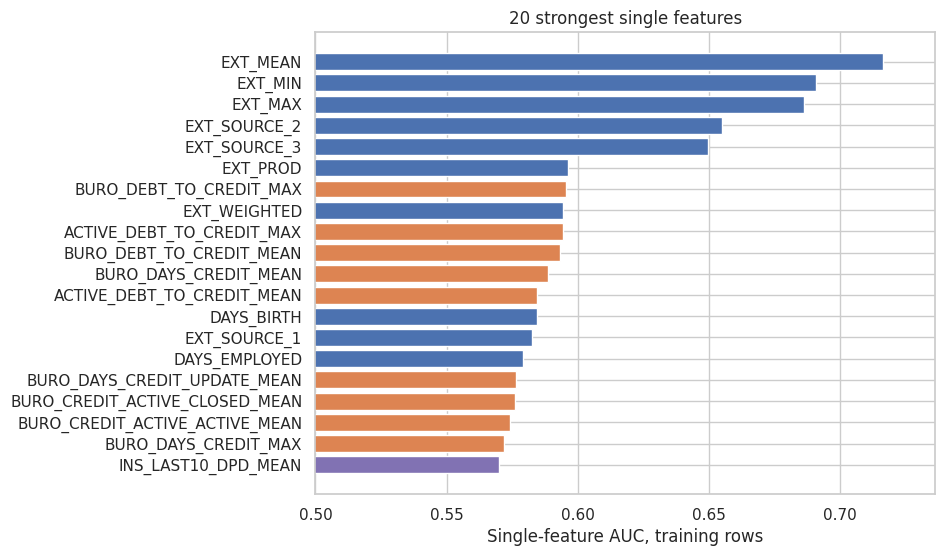

In [10]:
train_mask = split["is_holdout"].to_numpy() == 0
y_train = target.to_numpy()[train_mask]
single = {}
for col in features.columns:
    x = features[col].to_numpy()[train_mask]
    fill = np.nanmedian(x) if np.isfinite(x).any() else 0.0
    score = roc_auc_score(y_train, np.where(np.isnan(x), fill, x))
    single[col] = max(score, 1 - score)
uni = pd.DataFrame({"auc": pd.Series(single), "group": pd.Series(groups)}).sort_values("auc", ascending=False)
print(uni.head(25).round(4).to_string())
print(uni.groupby("group")["auc"].agg(["count", "max", "mean"]).round(4).to_string())
top = uni.head(20).iloc[::-1]
palette = dict(zip(sorted(uni["group"].unique()), sns.color_palette("deep", uni["group"].nunique())))
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top["auc"], color=[palette[g] for g in top["group"]])
ax.set_xlim(0.5, top["auc"].max() + 0.02)
ax.set_xlabel("Single-feature AUC, training rows")
ax.set_title("20 strongest single features")
save(fig, "02_univariate_auc")

**Conclusion.** The composite EXT_MEAN is the strongest single feature with an AUC of 0.716, ahead of every individual source (the best, EXT_SOURCE_2, reaches 0.655), which confirms the value of combining them. Bureau debt ratios such as BURO_DEBT_TO_CREDIT_MAX (0.595) are the strongest history features, and recent instalment behaviour such as INS_LAST10_DPD_MEAN (0.570) gives the instalment group the highest average AUC of any group (0.544). Most features are weak on their own, with group averages between 0.515 and 0.544, so the model's strength has to come from combining hundreds of them.

## Write the outputs

Aim: save the feature matrix with target, segment labels and exposure, the split, and the feature metadata (source group per feature, category labels for label-encoded columns) for notebooks 3, 4 and 5.

In [11]:
out = features.reset_index()
out.insert(1, "TARGET", target.to_numpy())
out = out.join(segments, on="SK_ID_CURR")
out.to_parquet(OUT / "features.parquet", index=False)
split.to_parquet(OUT / "split.parquet", index=False)
meta = {"features": list(features.columns), "groups": groups, "categorical": {k: v for k, v in categorical.items() if k in features.columns}}
(OUT / "feature_meta.json").write_text(json.dumps(meta))
for name in ["features.parquet", "split.parquet", "feature_meta.json"]:
    print(f"{name}: {(OUT / name).stat().st_size / 1e6:.1f} MB")
print(f"elapsed {elapsed()}")

features.parquet: 305.2 MB
split.parquet: 1.6 MB
feature_meta.json: 0.1 MB
elapsed 5.5 min


**Conclusion.** The feature matrix was written as a 305 MB parquet file alongside the split and the feature metadata. Notebooks 3, 4 and 5 read these files directly as kernel inputs.

## Summary

- One row per applicant for all 307,511 applicants, with 836 features drawn from the application, bureau, bureau balance, previous application, POS and cash, credit card and instalment tables.
- The `DAYS_EMPLOYED` placeholder is a missing value plus a flag, the external scores are combined into composites, and amounts are expressed as ratios, as the EDA suggested.
- History is aggregated over all records, over meaningful subsets (active and closed bureau loans, approved and refused applications) and over recent windows, and 7 cross-table ratios relate total debt and annuity burden to income.
- The holdout is fixed at 61,503 applicants (20%, stratified, seed 42) before any model exists.
- Single-feature AUCs top out at 0.716, so the gains must come from the model combining many weak signals, which is the job of notebooks 3 and 4.